# Coastal Groundwater Level Prediction — Model Training & Evaluation

This notebook covers:
1. Data loading and preprocessing
2. Hyperparameter tuning with 7-fold cross-validated grid search (on training set)
3. Model evaluation on a held-out 20 % test set
4. Feature importance and partial dependence analysis
5. Sea-level threshold classification performance (ROC / confusion matrix)
6. Baseline spatial prediction on the national 250 m model grid

**Run `02_scenario_analysis.ipynb` afterwards** to apply the saved model under
future climate scenarios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    root_mean_squared_error, r2_score, mean_absolute_error,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
# ── Paths (update DATA_DIR to point at your local data folder) ───────────────
DATA_DIR   = "data"
TRAIN_CSV  = f"{DATA_DIR}/Coastal_Komanawa_BoreParams_Mar2025(in).csv"
GRID_CSV   = f"{DATA_DIR}/modelGrid_March2025.csv"
MODEL_PATH = f"rf_groundwater_model.joblib"
OUTPUT_CSV = f"{DATA_DIR}/Predicted_GWL_baseline.csv"

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# ── Well filter ───────────────────────────────────────────────────────────────
MAX_WELL_DEPTH = 50  # metres; restrict to shallow coastal wells

# ── Predictor features and target ────────────────────────────────────────────
FEATURES = [
    "SoilType", "SoilDrain", "GeolAge", "MainRock",
    "FlowFRE3", "FlowMALF", "RainFall",
    "easting", "northing", "closest_coastal_distance", "ground_elevation",
]
TARGET = "GWL_median"

## 1. Data Loading & Preprocessing

In [3]:
df = pd.read_csv(TRAIN_CSV)
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded 50,620 rows, 19 columns


,site_name,region,source,well_depth,gwL_source,reading_co,easting,northing,closest_coastal_distance,ground_elevation,GWL_median,SoilType,SoilDrain,GeolAge,MainRock,SubRock,FlowFRE3,FlowMALF,RainFall
0,0090TeRapaVineyardWell_mdc,Marlborough,mdc,NaN,logger,228,1689478,5362109,3612.445188,36.7,42.8,1,5,0.007,1.0,2.0,8.912939,-5.826091,676.799988
1,0108WardWaterScheme_mdc,Marlborough,mdc,NaN,logger,148,1695251,5370989,4483.449045,24.3,21.6,2,4,0.007,1.0,2.0,8.882574,-5.694880,747.400024
2,0112TeRapaWell_mdc,Marlborough,mdc,NaN,logger,260,1689858,5361994,3266.451857,31.9,36.9,1,0,0.007,1.0,2.0,8.912939,-5.826091,669.400024
3,0121RobrianEstate_mdc,Marlborough,mdc,NaN,logger,58,1695397,5370819,4272.209360,21.3,17.5,2,4,0.007,1.0,2.0,8.882574,-5.694880,747.400024
4,0141RuddWell_mdc,Marlborough,mdc,NaN,logger,260,1691367,5361153,1609.787314,17.4,18.2,1,5,0.007,1.0,2.0,8.912939,-5.826091,676.299988


In [4]:
df.replace(-9999, np.nan, inplace=True)
df.dropna(inplace=True)
df["MainRock"] = df["MainRock"].astype(int)
df["closest_coastal_distance"] = df["closest_coastal_distance"] / 1000  # m → km

print(f"After cleaning: {df.shape[0]:,} rows")

After cleaning: 49,786 rows


## 2. Hyperparameter Tuning & Model Training

A 7-fold cross-validated grid search identifies the best Random Forest
hyperparameters using only the training set. The optimal model is then
evaluated on the held-out 20 % test set to report unbiased performance.

In [5]:
df_model = df[df["well_depth"] <= MAX_WELL_DEPTH].copy()
print(f"Wells with depth \u2264 {MAX_WELL_DEPTH} m: {len(df_model):,}")

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

Wells with depth ≤ 50 m: 46,677


In [6]:
param_grid = {
    "n_estimators":     [100, 200, 300, 500],
    "max_features":     ["sqrt", "log2", None],
    "min_samples_leaf": [1, 2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED),
    param_grid,
    cv=7,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV R\u00b2      : {grid_search.best_score_:.4f}")

Fitting 7 folds for each of 36 candidates, totalling 252 fits


/home/rqiu/miniforge3/envs/groundwater/lib/python3.10/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'fffffff\xe6\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
/home/rqiu/miniforge3/envs/groundwater/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters : {'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV R²      : 0.9930


In [7]:
best_model = grid_search.best_estimator_
joblib.dump(best_model, MODEL_PATH)
print(f"Model saved \u2192 {MODEL_PATH}")

Model saved → rf_groundwater_model.joblib


## 3. Model Evaluation

All metrics below are computed on the held-out 20 % test set.

In [8]:
y_pred = best_model.predict(X_test)

rmse  = root_mean_squared_error(y_test, y_pred)
mae   = mean_absolute_error(y_test, y_pred)
r2    = r2_score(y_test, y_pred)
nrmse = (rmse / (y_test.max() - y_test.min())) * 100

print(f"R\u00b2     : {r2:.4f}")
print(f"RMSE   : {rmse:.4f} m")
print(f"nRMSE  : {nrmse:.2f} %")
print(f"MAE    : {mae:.4f} m")

R²     : 0.9927
RMSE   : 2.1321 m
nRMSE  : 0.50 %
MAE    : 1.0490 m


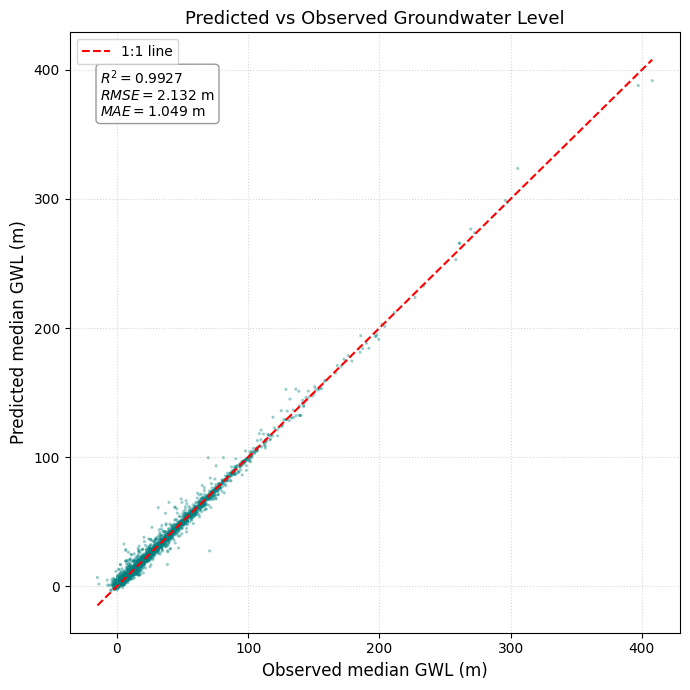

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.4, s=5, color="teal", edgecolors="none")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="1:1 line")

ax.set_xlabel("Observed median GWL (m)", fontsize=12)
ax.set_ylabel("Predicted median GWL (m)", fontsize=12)
ax.set_title("Predicted vs Observed Groundwater Level", fontsize=13)
ax.annotate(
    f"$R^2 = {r2:.4f}$\n$RMSE = {rmse:.3f}$ m\n$MAE = {mae:.3f}$ m",
    xy=(0.05, 0.86), xycoords="axes fraction",
    bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.8),
)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Importance

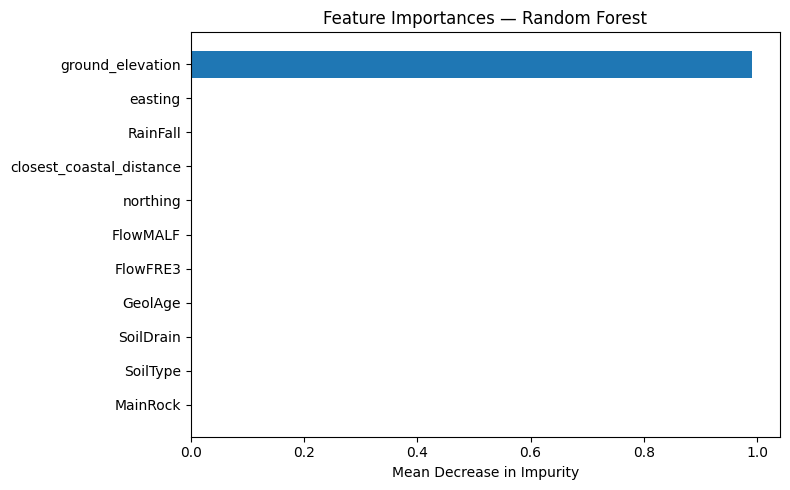

In [10]:
importances = best_model.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(idx)), importances[idx], align="center")
ax.set_yticks(range(len(idx)), [FEATURES[i] for i in idx])
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

### Partial Dependence Plots

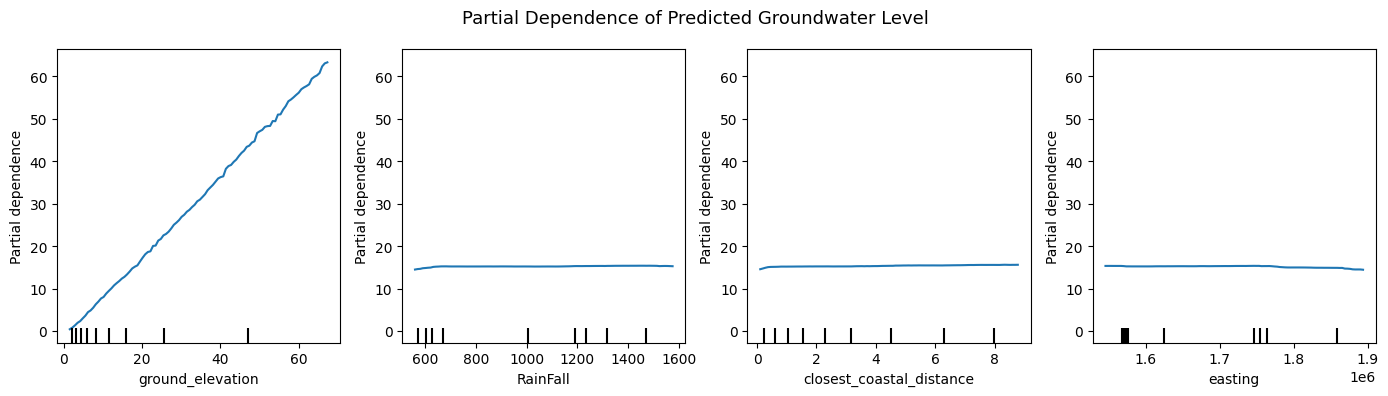

In [11]:
features_pdp = ["ground_elevation", "RainFall", "closest_coastal_distance", "easting"]

fig, axes = plt.subplots(1, len(features_pdp), figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=features_pdp,
    kind="average", ax=axes, n_jobs=-1,
)
plt.suptitle("Partial Dependence of Predicted Groundwater Level", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Sea-Level Threshold Analysis

Using 0 m as the sea-level decision boundary, we assess how well the
regression model identifies wells with groundwater below sea level —
a key coastal hazard indicator.

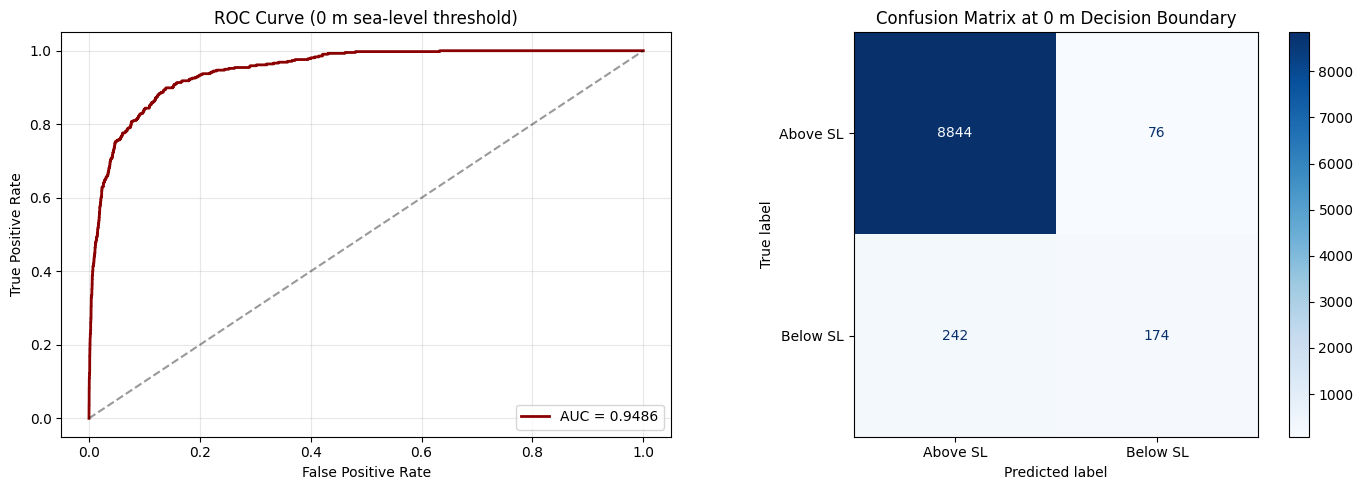

ROC AUC: 0.9486


In [12]:
y_true_bin = (y_test <= 0).astype(int)
y_pred_bin = (y_pred <= 0).astype(int)
y_scores   = -y_pred  # higher score → more likely below sea level

fpr, tpr, _ = roc_curve(y_true_bin, y_scores)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_true_bin, y_pred_bin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr, tpr, color="darkred", lw=2, label=f"AUC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve (0 m sea-level threshold)")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

ConfusionMatrixDisplay(cm, display_labels=["Above SL", "Below SL"]).plot(
    ax=ax2, cmap="Blues", values_format="d"
)
ax2.set_title("Confusion Matrix at 0 m Decision Boundary")
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

## 5. Baseline Spatial Prediction

Apply the trained model to the national 250 m model grid to produce
spatially continuous groundwater level estimates under current (baseline)
climate conditions.

In [13]:
grid = pd.read_csv(GRID_CSV)
grid = grid.rename(columns={
    "Rainfall": "RainFall",
    "Easting":  "easting",
    "Northing": "northing",
    "ground_ele": "ground_elevation",
    "distance_t": "closest_coastal_distance",
})
grid["closest_coastal_distance"] = grid["closest_coastal_distance"] / 1000
grid["MainRock"] = grid["MainRock"].astype(int)
grid.drop(columns=["FID", "Shape"], inplace=True)
grid.replace(-9999, np.nan, inplace=True)
grid.dropna(inplace=True)

print(f"Model grid: {len(grid):,} points")

Model grid: 473,984 points


In [14]:
model = joblib.load(MODEL_PATH)
grid["predicted_GWL"] = model.predict(grid[FEATURES])

grid.to_csv(OUTPUT_CSV, index=False)
print(f"Predictions saved \u2192 {OUTPUT_CSV}")
print(f"\nPredicted GWL summary (m):")
print(grid["predicted_GWL"].describe().round(3))

Predictions saved → /home/rqiu/Documents/Groundwater_modelling/data/Predicted_GWL_baseline.csv

Predicted GWL summary (m):
count    473984.000
mean         67.808
std          83.795
min          -6.064
25%          11.135
50%          37.456
75%          89.657
max         481.525
Name: predicted_GWL, dtype: float64
